# Customer Segmentation Analysis
## Tools & Technologies

- Excel (Pivot Tables, Dashboard)
- Python (Pandas, Matplotlib, Seaborn)
- SQL (SQLite)

## Problem Statement

The objective of this project is to analyze customer behavior in a shopping mall dataset and identify patterns in spending based on demographic factors such as age, gender, and income.

The goal is to derive actionable business insights that can help improve customer targeting and marketing strategies.

## Project Workflow

1. Data Collection – Imported customer dataset (CSV)
2. Data Cleaning – Processed and structured data using Python (Pandas)
3. Feature Engineering – Created Age Groups and Income Groups
4. Data Analysis – Performed analysis using Python and SQL
5. Visualization – Built charts using Python and Excel dashboard
6. Insights & Recommendations – Derived business insights and strategies

In [15]:
import seaborn as sns
sns.set_style("whitegrid")
sns.set_palette("mako")

In [6]:
import pandas as pd

df = pd.read_csv("mall_data.csv")
df.head()

,Customer ID,Age,Gender,Annual Income,Spending Score,Age Group,Income group
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30.0,Male,151479.0,89.0,Adult,High
1,1770b26f-493f-46b6-837f-4237fb5a314e,58.0,Female,185088.0,95.0,Middle Age,High
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62.0,Female,70912.0,76.0,Senior,Medium
3,9795712a-ad19-47bf-8886-4f997d6046e3,23.0,Male,55460.0,57.0,Young,Medium
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24.0,Male,153752.0,76.0,Young,High


## Gender vs Spending Analysis

In [2]:
df.groupby('Gender')['Spending Score'].mean()

Gender
Female    50.397648
Male      50.782752
Name: Spending Score, dtype: float64

## Age Group Segmentation

In [3]:
bins = [0,25,40,60,100]
labels = ['Young','Adult','Middle Age','Senior']
df['Age_Group'] = pd.cut(df['Age'], bins=bins, labels=labels)

df.groupby('Age_Group')['Spending Score'].mean()

Age_Group
Young         51.843516
Adult         50.241413
Middle Age    50.923768
Senior        50.225445
Name: Spending Score, dtype: float64

## Income Group Segmentation

In [10]:
bins = [0,50000,100000,200000]
labels = ['Low','Medium','High']
df['Income_Group'] = pd.cut(df['Annual Income'], bins=bins, labels=labels)

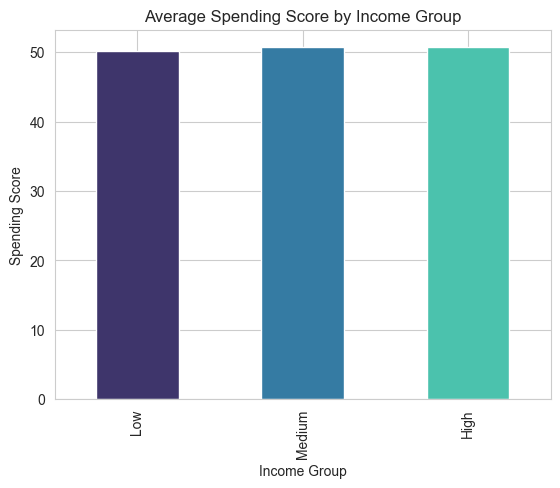

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create data
income_spending = df.groupby('Income_Group')['Spending Score'].mean()

# Apply mako color palette
colors = sns.color_palette("mako", 3)

# Plot graph
income_spending.plot(kind='bar', color=colors)

plt.title("Average Spending Score by Income Group")
plt.xlabel("Income Group")
plt.ylabel("Spending Score")

plt.show()

## 📊 Key Insights

- Spending is consistent across income groups  
- Gender has minimal impact on spending  
- Middle-aged customers show slightly higher spending  
- No single factor dominates customer behavior  

##  Conclusion

Customer segmentation shows that spending behavior is relatively uniform across demographics, indicating that marketing strategies should focus on combined factors rather than a single variable.

## SQL Analysis

- Performed customer segmentation using SQLite
- Used CASE WHEN to create Age and Income groups
- Analyzed average spending behavior across demographics
- Found that spending is relatively uniform across segments

In [6]:
df = pd.read_csv("mall_data.csv")

In [7]:
import sqlite3

conn = sqlite3.connect("mall.db")

df.to_sql("customers", conn, if_exists="replace", index=False)

15079

In [8]:
pd.read_sql("SELECT * FROM customers LIMIT 5;", conn)

,Customer ID,Age,Gender,Annual Income,Spending Score,Age Group,Income group
0,d410ea53-6661-42a9-ad3a-f554b05fd2a7,30.0,Male,151479.0,89.0,Adult,High
1,1770b26f-493f-46b6-837f-4237fb5a314e,58.0,Female,185088.0,95.0,Middle Age,High
2,e81aa8eb-1767-4b77-87ce-1620dc732c5e,62.0,Female,70912.0,76.0,Senior,Medium
3,9795712a-ad19-47bf-8886-4f997d6046e3,23.0,Male,55460.0,57.0,Young,Medium
4,64139426-2226-4cd6-bf09-91bce4b4db5e,24.0,Male,153752.0,76.0,Young,High


In [9]:
query = """
SELECT Gender, AVG(`Spending Score`) as avg_spending
FROM customers
GROUP BY Gender;
"""

pd.read_sql(query, conn)

,Gender,avg_spending
0,Female,50.397648
1,Male,50.782752


In [10]:
query = """
SELECT 
    CASE 
        WHEN `Annual Income` < 50000 THEN 'Low'
        WHEN `Annual Income` BETWEEN 50000 AND 100000 THEN 'Medium'
        ELSE 'High'
    END as Income_Group,
    AVG(`Spending Score`) as avg_spending
FROM customers
GROUP BY Income_Group;
"""

pd.read_sql(query, conn)

,Income_Group,avg_spending
0,High,50.687560
1,Low,50.125923
2,Medium,50.687173


In [11]:
query = """
SELECT 
    CASE 
        WHEN Age < 25 THEN 'Young'
        WHEN Age BETWEEN 25 AND 40 THEN 'Adult'
        WHEN Age BETWEEN 40 AND 60 THEN 'Middle Age'
        ELSE 'Senior'
    END as Age_Group,
    AVG(`Spending Score`) as avg_spending
FROM customers
GROUP BY Age_Group;
"""

pd.read_sql(query, conn)

,Age_Group,avg_spending
0,Adult,50.132104
1,Middle Age,50.923768
2,Senior,50.225445
3,Young,52.318923
